In [1]:
import pandas as pd
df = pd.read_csv("mock_lenses_hsc.csv")
df

,objID,objID_src,rot,x_lens,y_lens,q,PA,r_Einstein,z_source,z_lens,velDisp,x_source,y_source,boost,shear,shear_PA
0,1,1090,0,0.038127,-0.083938,0.832873,1.099377,2.454128,3.127611,0.730786,378.07416,-0.279477,-0.477602,-1.0,0.022431,0.911779
1,2,426,0,-0.082791,-0.109870,0.742644,1.852767,2.468242,5.798559,0.441585,329.32822,-0.074636,-0.380427,-3.0,0.059983,0.958381
2,3,2136,0,-0.054644,-0.008364,0.845785,2.936826,2.475322,4.785457,0.454826,333.96304,-0.133183,-0.277230,-3.0,0.038890,1.134869
3,4,7141,0,-0.030885,-0.070501,0.857919,2.483655,2.456651,4.792636,0.819645,369.14502,-0.133090,-0.034229,-4.0,0.005173,2.657499
4,5,7215,0,-0.038541,0.001391,0.899268,0.382301,2.497800,4.860585,0.703609,359.74615,-0.318418,-0.027564,-4.0,0.043490,1.112804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43728,51996,1083,1,0.012901,-0.058693,0.867499,1.836198,0.776824,0.827810,0.415259,248.21088,0.057228,-0.057947,-4.0,0.054220,2.249565
43729,51997,12,2,-0.001551,0.024924,0.808340,2.464540,0.756855,0.996663,0.422812,228.52315,-0.070151,-0.063773,-3.0,0.029062,2.235106
43730,51998,11,0,0.006303,-0.002664,0.750802,2.697964,0.792795,1.037593,0.484768,245.66832,-0.018803,-0.008539,-1.0,0.045575,2.531362
43731,51999,1273,0,0.046707,0.056492,0.853459,1.348237,0.786784,2.172062,0.494431,204.68020,0.006797,-0.021310,-1.0,0.041806,2.955045


In [2]:
import numpy as np
df['ex'] = np.cos(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)
df['ey'] = np.sin(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)

In [3]:
df['qq'] = np.sqrt((1 - np.sqrt(df.ex **2 + df.ey**2)) / (1 + np.sqrt(df.ex **2 + df.ey**2)) )
df['diff'] = df.q - df.qq

In [4]:
df['gamma1'] = np.cos(2 * df.shear_PA) * df.shear
df['gamma2'] = np.sin(2 * df.shear_PA) * df.shear

In [5]:
import os
os.chdir("/home/rcanameras/data/mock_lenses_hsc/")
# os.chdir("/home/mbatt")

In [6]:
folders = [f for f in os.listdir() if 'csv' not in f]

dict_im = {}
for fold in folders: 
    for file in os.listdir(fold):
        if '.fits' in file:
            objID = int(file.split('_')[1])
            dict_im[objID] = [fold + "/" + file]

In [7]:
df_im = pd.DataFrame(dict_im).T
df_im = df_im.reset_index()
df_im.columns = ["objID", "location"]

In [8]:
df_full = df.merge(df_im, on = "objID", how = 'left')

In [9]:
df_sample = df_full#.sample(n=2000, random_state=42)

In [10]:
dff = df_sample[['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey', 'location']]
dff = dff.set_index("location")

In [11]:
cols_to_norm = ['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey']
dff[cols_to_norm] = (dff[cols_to_norm] - dff[cols_to_norm].min()) / (dff[cols_to_norm].max() - dff[cols_to_norm].min())

In [12]:
dff = dff.sample(frac=1, random_state=42)

In [13]:
import os
os.chdir('/home/mbatt/gravitational_lensing')

In [14]:
from deep_learning_models import *
from deep_learning_models import LensDataset

In [15]:
import torch
from torch.utils.data import random_split

path_tensor = "/home/mbatt/data"
full_dataset = LensDataset_UNet(dff, path_tensor)
# full_dataset = LensDataset(dff, path_tensor)

train_loader, val_loader, test_loader = full_dataset.split_data(training_pct = 0.6, # 60% for training
                                                                test_pct = 0.2, # 20% for test
                                                                batch_size = 32)

In [16]:
from deep_learning_models import UNetThenNN

In [17]:
import os
os.chdir("/home/mbatt/gravitational_lensing")

In [18]:
# model = ResNetMini()   
# model = BayesianResNetMini()
model = UNetThenResNet()
# model = UNet()
# model = UNetBayesian()
# model = UNetThenNN()
# model = ResNetHoliSmokesBayesian()
# model = ResNetHoliSmokes()

In [19]:
model.model_name

'UNetThenResNet'

In [20]:
# vv = viewer(model)
# vv.show_model()

In [21]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 4,621,257
Trainable parameters: 4,621,257


In [22]:
from process_training import Trainer
import warnings
warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
from torch.optim.lr_scheduler import ReduceLROnPlateau


patience = 25
early_stop_counter = 0

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


train_losses = []
val_losses = []

best_val_loss = float('inf')
best_weights = None
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
# scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10)
scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer, step_size=10, gamma=0.5)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=100)

best_val_loss = float('inf')
best_weights = None

In [24]:
# mettre poids plus important sur le shear que sur le Rayon d'einstein pour mieux le retrouver
# mettre incertidues sur le transformer 
def gaussian_nll(mu, log_var, y, beta=0.005):
    log_var = torch.clamp(log_var, -10, 10)
    precision = torch.exp(-log_var)
    nll = 0.5 * (precision * (y - mu)**2 + log_var)
    # Pénalise les log_var trop extrêmes
    reg = beta * (log_var ** 2).mean()
    return nll.mean() + reg

In [25]:
# import time 
# import copy
# import torch

# # N_MC = 1000  # number of MC samples for epistemic uncertainty at val time
# model.to(device)
# start = time.time()

# for epoch in range(100):
#     # ---- TRAIN ----
#     # single forward pass per batch, dropout active via training=True hardcoded in forward()
#     model.train()
#     epoch_loss = 0.0
#     for xb, yb in train_loader:
#         xb, xout = xb[0].to(device), xb[1].to(device)
#         yb, paths = yb[0].to(device), yb[1]
#         optimizer.zero_grad()
#         out_lens = model.forward_unet(xb)
# #                 out_lens = torch.cat([out_lens, xb - out_lens], dim=1)
#         mu, log_var = model.forward_resnet(out_lens)
#         # mu, log_var = model(xb)                    # aleatoric: mu + log_var predicted by network
#         loss = gaussian_nll(mu, log_var, yb)
#         loss.backward()
#         optimizer.step()
#         epoch_loss += loss.item()
#     train_losses.append(epoch_loss / len(train_loader))

#     print(f"log_var mean: {log_var.mean():.3f}, std: {log_var.std():.3f}")
#     # print(f"mu residuals std: {(mu - y).std():.4f}")

#    # ---- VALIDATION ----
#     model.eval()
#     val_loss = 0.0
#     with torch.no_grad():
#         for xb, yb in val_loader:
#             xb, xout = xb[0].to(device), xb[1].to(device)
#             yb, paths = yb[0].to(device), yb[1]
#             out_lens = model.forward_unet(xb)
#             mu, log_var = model.forward_resnet(out_lens)
            
#             # mu, log_var = model(xb)
#             loss = gaussian_nll(mu, log_var, yb)
#             val_loss += loss.item()
#     val_losses.append(val_loss / len(val_loader))
#     scheduler.step()

#     # ---- EARLY STOPPING ----
#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         best_weights = copy.deepcopy(model.state_dict())
#         early_stop_counter = 0
#     else:
#         early_stop_counter += 1
#     print(f"Epoch {epoch+1}: train={train_losses[-1]:.4f}, val={val_losses[-1]:.4f}")
#     if early_stop_counter >= patience:
#         print(f"Early stopping triggered at epoch {epoch+1}")
#         break
# process_time = time.time() - start

In [26]:
# import os
# import torch

# os.chdir("/home/mbatt/gravitational_lensing/")

# checkpoint = {
#     "model_state_dict": best_weights,   # your best Bayesian model weights
#     "optimizer_state_dict": optimizer.state_dict(),
#     "epoch": epoch,
#     "train_losses": train_losses,
#     "val_losses": val_losses,
#     "process_time": process_time
# }
# torch.save(checkpoint, "resnet_unet_bayesian_1.pth")

In [27]:
# for name, p in model.named_parameters():
#     if 'logvar' in name and p.grad is not None:
#         print(f"{name} grad norm: {p.grad.norm():.6f}")

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import os

os.chdir("/home/mbatt/gravitational_lensing")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
# optimizer = optim.Adam(model.parameters(), lr=1e-5)

checkpoint = torch.load("resnet_bayesian_9.pth", map_location=device)
# checkpoint = torch.load("ResNetHoliSmokes_20.pth", map_location=device)
# checkpoint = torch.load("resnet_unet_bayesian_1.pth", map_location=device)
checkpoint = torch.load("UNetThenResNet_16.pth", map_location=device)


# model.load_state_dict(checkpoint["model_state_dict"])
model.load_state_dict(checkpoint["model"])
# optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

start_epoch = checkpoint["epoch"] + 1

train_losses = checkpoint["train_losses"]
val_losses = checkpoint["val_losses"]


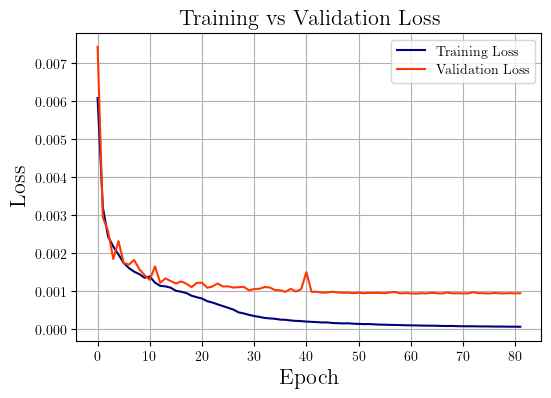

In [29]:
import matplotlib.pyplot as plt
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Training Loss", color = '#00007F', linewidth = 1.5)
plt.plot(val_losses, label="Validation Loss", color = '#FF3700', linewidth = 1.5)
plt.xlabel("Epoch", fontsize = 16)
plt.ylabel("Loss", fontsize = 16)
plt.title("Training vs Validation Loss", fontsize = 16)
plt.legend()
plt.grid(True)
plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/bayes_loss.png", dpi=300, bbox_inches="tight")
plt.show()


In [35]:
import time
model.eval()
preds_mu = []
preds_std = []
targets = []
epistemic = []

criterion = nn.MSELoss(reduction="none")
i = 0
with torch.no_grad():
    for xb, yb in test_loader:   # <-- use test_loader here
        # print(f"batch {i}")
        # i += 1
        # xb = xb.to(device)
        xb, xout = xb[0].to(device), xb[1].to(device)
        # yb, _ = yb[0].to(device), yb[1]
        yb, paths = yb[0].to(device), yb[1]

        optimizer.zero_grad()

        # ---- Forward pass ----
        # Sampling 
        # start = time.time()
        # out_lens = model.forward_unet(xb)
        # muu = model.forward_resnet(out_lens)
        muu = model(xb)
        preds_mu.append(muu.cpu())
        # preds_std.append(logvvv.cpu())
        # epistemic.append(ouuts.std(axis = 2))
        targets.append(yb.cpu())

# concatenate all batches
preds_mu = np.concatenate(preds_mu, axis = 0)      # shape (N, 5)
# preds_std = np.concatenate(preds_std, axis = 0)
# epistemic = np.concatenate(epistemic, axis = 0)
targets = np.concatenate(targets, axis = 0)  # shape (N, 5)

In [44]:
a =((preds_mu - targets)/targets).mean(axis = 0)
a


array([ 0.41701874,  0.45928934,  0.55600053,  0.01371672, -0.00677892],
      dtype=float32)

In [31]:
import time
model.eval()
preds_mu = []
preds_std = []
targets = []
epistemic = []

criterion = nn.MSELoss(reduction="none")
i = 0
with torch.no_grad():
    for xb, yb in test_loader:   # <-- use test_loader here
        print(f"batch {i}")
        i += 1
        # xb = xb.to(device)
        xb, xout = xb[0].to(device), xb[1].to(device)
        # xb = xb[:,:-1,:,:]
        yb, paths = yb[0].to(device), yb[1]

        optimizer.zero_grad()

        # ---- Forward pass ----
        # Sampling 
        start = time.time()
        muu, logvvv = model(xb)
        preds_mu.append(muu.cpu())
        preds_std.append(logvvv.cpu())
        # epistemic.append(ouuts.std(axis = 2))
        targets.append(yb.cpu())

# concatenate all batches
preds_mu = np.concatenate(preds_mu, axis = 0)      # shape (N, 5)
preds_std = np.concatenate(preds_std, axis = 0)
# epistemic = np.concatenate(epistemic, axis = 0)
targets = np.concatenate(targets, axis = 0)  # shape (N, 5)

batch 0
batch 1
batch 2
batch 3
batch 4
batch 5
batch 6
batch 7
batch 8
batch 9
batch 10
batch 11
batch 12
batch 13
batch 14
batch 15
batch 16
batch 17
batch 18
batch 19
batch 20
batch 21
batch 22
batch 23
batch 24
batch 25
batch 26
batch 27
batch 28
batch 29
batch 30
batch 31
batch 32
batch 33
batch 34
batch 35
batch 36
batch 37
batch 38
batch 39
batch 40
batch 41
batch 42
batch 43
batch 44
batch 45
batch 46
batch 47
batch 48
batch 49
batch 50
batch 51
batch 52
batch 53
batch 54
batch 55
batch 56
batch 57
batch 58
batch 59
batch 60
batch 61
batch 62
batch 63
batch 64
batch 65
batch 66
batch 67
batch 68
batch 69
batch 70
batch 71
batch 72
batch 73
batch 74
batch 75
batch 76
batch 77
batch 78
batch 79
batch 80
batch 81
batch 82
batch 83
batch 84
batch 85
batch 86
batch 87
batch 88
batch 89
batch 90
batch 91
batch 92
batch 93
batch 94
batch 95
batch 96
batch 97
batch 98
batch 99
batch 100
batch 101
batch 102
batch 103
batch 104
batch 105
batch 106
batch 107
batch 108
batch 109
batch 110


In [32]:
preds_std

array([[-5.3461394, -3.5847127, -3.5961416, -5.9778576, -6.       ],
       [-4.058148 , -3.3341293, -3.4298933, -6.       , -6.       ],
       [-6.       , -3.5388594, -3.5248892, -6.       , -6.       ],
       ...,
       [-5.5765486, -3.4679067, -3.5111258, -6.       , -6.       ],
       [-5.8780255, -3.4562516, -3.527412 , -6.       , -6.       ],
       [-5.3750863, -3.4852242, -3.4945107, -6.       , -6.       ]],
      dtype=float32)

In [33]:
np.sqrt(np.exp(preds_std))

array([[0.06903996, 0.16656722, 0.16561809, 0.05034133, 0.04978707],
       [0.1314572 , 0.18880044, 0.17997332, 0.04978707, 0.04978707],
       [0.04978707, 0.17043015, 0.1716248 , 0.04978707, 0.04978707],
       ...,
       [0.0615273 , 0.17658493, 0.17280993, 0.04978707, 0.04978707],
       [0.05291795, 0.17761698, 0.17140844, 0.04978707, 0.04978707],
       [0.06804792, 0.1750625 , 0.17425156, 0.04978707, 0.04978707]],
      dtype=float32)

In [36]:
from torch.utils.data import random_split, DataLoader

dataset = test_loader.dataset  # <-- extract dataset

full_size = len(dataset)
cal_size = int(1 * full_size)
test_size = full_size - cal_size

cal_dataset, test_dataset = random_split(dataset, [cal_size, test_size])

cal_loader = DataLoader(cal_dataset, batch_size=val_loader.batch_size, shuffle=False)
cal_test_loader = DataLoader(test_dataset, batch_size=val_loader.batch_size, shuffle=False)

In [37]:
import torch

mus, aleatoric, errors, target, epistemic = [], [], [], [], []

# model.eval()
hhuh = 0
with torch.no_grad():
    for xb, yb in cal_loader:
        print(hhuh)
        hhuh += 1
        # xb = xb.to(device)
        xb, xout = xb[0].to(device), xb[1].to(device)
        yb = yb[0].to(device)

        
        mu_samples = []
        sigma_samples = []

        for _ in range(100):
            mu, sigma = model(xb)

            mu_samples.append(mu.cpu())
            sigma_samples.append(sigma.cpu())

        # Shape: [100, batch_size, n_params]
        mu_samples = torch.stack(mu_samples, dim=0)
        sigma_samples = torch.stack(sigma_samples, dim=0)
        mean_pred = mu_samples.mean(dim=0)
        epistemic_unc = mu_samples.std(dim=0)
        
        aleatoric_unc = sigma_samples.mean(dim=0)
        
        mus.append(mean_pred)
        epistemic.append(epistemic_unc)
        aleatoric.append(aleatoric_unc)
        target.append(yb.cpu())
        errors.append(
            (yb.cpu() - mean_pred) ** 2
        )
mus = torch.cat(mus, dim=0).numpy()
epistemic = torch.cat(epistemic, dim=0).numpy()
aleatoric = torch.cat(aleatoric, dim=0).numpy()
target = torch.cat(target, dim=0).numpy()
errors = torch.cat(errors, dim=0).numpy()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273


In [30]:
def beta_func(x, a, b, c):
    return 1.0 / (1.0 + np.exp(-c * (x - a))) ** b

In [39]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.stats import norm

# plt.rcParams["text.usetex"] = True
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = ["Computer Modern Roman"]

# mu = mus.detach().cpu().numpy() if hasattr(mus, "detach") else mus
# sigma = sigmas.detach().cpu().numpy() if hasattr(sigmas, "detach") else sigmas
# sigma = np.sqrt(np.exp(sigma))
# y = target
# ii = 0
# # z-scores
# z = (y[:,ii] - mu[:,ii]) / (1 * sigma[:,ii])
# z = z.detach().cpu().numpy() if hasattr(z, "detach") else z

# # grid for smooth Gaussian curve
# x = np.linspace(-4, 4, 200)

# plt.figure()

# # empirical density
# plt.hist(z, bins=50, density=True, alpha=0.5, label="Empirical z density")

# # theoretical standard normal
# plt.plot(x, norm.pdf(x), label="N(0,1) PDF", linewidth=2)

# plt.xlabel("z-score")
# plt.ylabel("Density")
# plt.title("Z-score Density Calibration")
# plt.legend()
# plt.show()

In [31]:
df_uncertainties = pd.read_csv('uncertainties_bayes_unetresnet_4.csv', index_col = 0)

In [32]:
all_aleatoric = df_uncertainties[['r_Einstein_t_aleatoric', 'gamma1_aleatoric', 'gamma2_aleatoric',
       'ex_aleatoric', 'ey_aleatoric']].values
all_epistemic = df_uncertainties[['r_Einstein_t_epistemic',
       'gamma1_epistemic', 'gamma2_epistemic', 'ex_epistemic', 'ey_epistemic']].values

y = df_uncertainties[["r_Einstein_t_true",	"gamma1_true",	"gamma2_true",	"ex_true",	"ey_true"]].values
mu = df_uncertainties[["r_Einstein_t_pred",	"gamma1_pred",	"gamma2_pred",	"ex_pred",	"ey_pred"]].values

all_aleatoric = np.sqrt(np.exp(all_aleatoric))
all_epistemic = all_epistemic

sigma_tot = np.sqrt(all_aleatoric**2 + all_epistemic**2)


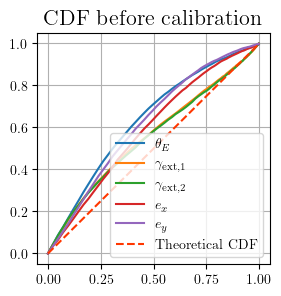

CDF calibration error: 0.08056652829354496


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

SS = []
# convert to numpy if needed
# mu = mus.detach().cpu().numpy() if hasattr(mus, "detach") else mus
# sigma = sigmas.detach().cpu().numpy() if hasattr(sigmas, "detach") else sigmas
# sigma_tot = np.sqrt(np.exp(aleatoric) + epistemic**2)
# y = target
param_names = [r"$\theta_E$", r"$\gamma_{\mathrm{ext,1}}$", r"$\gamma_{\mathrm{ext,2}}$", r"$e_x$", r"$e_y$"]
plt.figure(figsize = (3,3))
for ii in range(5):
    # compute z-scores
    z = (y[:,ii] - mu[:,ii]) / (1* sigma_tot[:,ii])
    z_abs = np.abs(z)
    k_values = np.linspace(0, 3, 100)
    empirical_cdf = []
    theoretical_cdf = []
    for k in k_values:
        empirical_cdf.append(np.mean(z_abs <= k))
        theoretical_cdf.append(2 * norm.cdf(k) - 1)
    empirical_cdf = np.array(empirical_cdf)
    theoretical_cdf = np.array(theoretical_cdf)
    plt.plot(theoretical_cdf, empirical_cdf, label=f'{param_names[ii]}')
    plt.title("CDF before calibration", fontsize = 16)
    plt.grid(True)

    from scipy.optimize import curve_fit
    p0 = [1.0, 1.0, 1.0]  # initial guess
    params, _ = curve_fit(
        beta_func,
        k_values,
        empirical_cdf,
        p0=p0,
        maxfev=10000
    )
    a, b, c = params
    s_grid = np.linspace(0, 4, 1000)
    
    def calibration_loss(s):
        z_scaled = (y[:,ii] - mu[:,ii]) / (s* sigma_tot[:,ii])
        z_abs_scaled = np.abs(z_scaled)
    
        emp = []
        for k in k_values:
            emp.append(np.mean(z_abs_scaled <= k))
        emp = np.array(emp)
    
        return np.mean((emp - theoretical_cdf) ** 2)
    
    losses = [calibration_loss(s) for s in s_grid]
    s_opt = s_grid[np.argmin(losses)]
    SS.append(s_opt)

plt.plot(np.linspace(0, 1, 100), np.linspace(0, 1, 100), linestyle="--", label="Theoretical CDF", color = '#FF3700')
plt.legend()
# plt.xticks(fontsize = 14)
# plt.yticks(fontsize = 14)
plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/cdf1.png", dpi=300, bbox_inches="tight")
plt.show()

# scalar calibration error
calibration_error = np.mean(np.abs(empirical_cdf - theoretical_cdf))
print("CDF calibration error:", calibration_error)

In [42]:
ii = 0
z = (y[:,ii] - mu[:,ii]) / (1* sigma_tot[:,ii])
np.mean(np.abs(z) <= 1)

0.8512462840155499

In [43]:
print(mu[:,ii].mean(), mu[:,ii].std())

0.51510555 0.268608


In [44]:
print(y[:,ii].mean(), y[:,ii].std())

0.51065445 0.2879809


In [45]:
print(sigma_tot[:,ii].mean(), sigma_tot[:,ii].std())

0.08286058 0.037294112


In [46]:
SS

[0.6486486486486487,
 0.8848848848848849,
 0.8968968968968969,
 0.7447447447447447,
 0.6766766766766766]

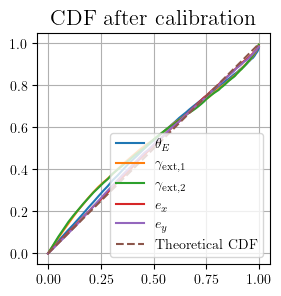

CDF calibration error: 0.012173593390828307


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]


# convert to numpy if needed
# mu = mus.detach().cpu().numpy() if hasattr(mus, "detach") else mus
# sigma = sigmas.detach().cpu().numpy() if hasattr(sigmas, "detach") else sigmas
# sigma = np.sqrt(np.exp(sigma))
# sigma_tot = np.sqrt(np.exp(aleatoric) + epistemic**2)
# y = target
plt.figure(figsize = (3,3))
for ii in range(5):
    z = (y[:,ii] - mu[:,ii]) / (SS[ii] * sigma_tot[:,ii])
    z_abs = np.abs(z)
    k_values = np.linspace(0, 3, 100)
    
    empirical_cdf = []
    theoretical_cdf = []
    
    for k in k_values:
        empirical_cdf.append(np.mean(z_abs <= k))
        theoretical_cdf.append(2 * norm.cdf(k) - 1)

    empirical_cdf = np.array(empirical_cdf)
    theoretical_cdf = np.array(theoretical_cdf)
    plt.plot(theoretical_cdf, empirical_cdf, label=param_names[ii])
    # plt.plot(np.linspace(0, 1, 100), np.linspace(0, 1, 100), linestyle="--", label="Theoretical CDF")

    plt.title("CDF after calibration", fontsize = 16)
    plt.grid(True)
plt.plot(np.linspace(0, 1, 100), np.linspace(0, 1, 100), linestyle="--", label="Theoretical CDF")
plt.legend()
plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/cdf2.png", dpi=300, bbox_inches="tight")
plt.show()

# scalar calibration error
calibration_error = np.mean(np.abs(empirical_cdf - theoretical_cdf))
print("CDF calibration error:", calibration_error)

In [48]:
ii = 0
z = (y[:,ii] - mu[:,ii]) / (SS[ii] * sigma_tot[:,ii])
np.mean(np.abs(z) <= 1)

0.702035216098788

In [49]:
SS

[0.6486486486486487,
 0.8848848848848849,
 0.8968968968968969,
 0.7447447447447447,
 0.6766766766766766]

In [30]:
import time
# model.train()
mus = []
aleatoric = []
target = []
epistemic = []
errors = []
PPP = ()

criterion = nn.MSELoss(reduction="none")
i = 0
with torch.no_grad():
    for xb, yb in test_loader:   # <-- use test_loader here
        print(f"batch {i}")
        i += 1
        
        # xb = xb.to(device)
        # xb = xb[:,:-1,:,:]
        xb, xout = xb[0].to(device), xb[1].to(device)
        yb, paths = yb[0].to(device), yb[1]

        optimizer.zero_grad()

        # ---- Forward pass ----
        # Sampling 
        start = time.time()

                
        mu_samples = []
        sigma_samples = []

        for _ in range(100):
            mu, sigma = model(xb)

            mu_samples.append(mu.cpu())
            sigma_samples.append(sigma.cpu())

        # Shape: [100, batch_size, n_params]
        mu_samples = torch.stack(mu_samples, dim=0)
        sigma_samples = torch.stack(sigma_samples, dim=0)
        mean_pred = mu_samples.mean(dim=0)
        epistemic_unc = mu_samples.std(dim=0)
        
        aleatoric_unc = sigma_samples.mean(dim=0)
        mus.append(mean_pred)
        epistemic.append(epistemic_unc)
        aleatoric.append(aleatoric_unc)
        target.append(yb.cpu())
        errors.append(
            (yb.cpu() - mean_pred) ** 2
        )
        PPP += paths
preds_mu = torch.cat(mus, dim=0).numpy()
epistemic = torch.cat(epistemic, dim=0).numpy()
preds_std = torch.cat(aleatoric, dim=0).numpy()
targets = torch.cat(target, dim=0).numpy()
errors = torch.cat(errors, dim=0).numpy()

batch 0
batch 1
batch 2
batch 3
batch 4
batch 5
batch 6
batch 7
batch 8
batch 9
batch 10
batch 11
batch 12
batch 13
batch 14
batch 15
batch 16
batch 17
batch 18
batch 19
batch 20
batch 21
batch 22
batch 23
batch 24
batch 25
batch 26
batch 27
batch 28
batch 29
batch 30
batch 31
batch 32
batch 33
batch 34
batch 35
batch 36
batch 37
batch 38
batch 39
batch 40
batch 41
batch 42
batch 43
batch 44
batch 45
batch 46
batch 47
batch 48
batch 49
batch 50
batch 51
batch 52
batch 53
batch 54
batch 55
batch 56
batch 57
batch 58
batch 59
batch 60
batch 61
batch 62
batch 63
batch 64
batch 65
batch 66
batch 67
batch 68
batch 69
batch 70
batch 71
batch 72
batch 73
batch 74
batch 75
batch 76
batch 77
batch 78
batch 79
batch 80
batch 81
batch 82
batch 83
batch 84
batch 85
batch 86
batch 87
batch 88
batch 89
batch 90
batch 91
batch 92
batch 93
batch 94
batch 95
batch 96
batch 97
batch 98
batch 99
batch 100
batch 101
batch 102
batch 103
batch 104
batch 105
batch 106
batch 107
batch 108
batch 109
batch 110


In [42]:
# --- Compute R2 per parameter ---
y_true_np = targets
y_pred_np = preds_mu
preds_std_np = preds_std
epistemic_np =epistemic

r2_scores = []
for i in range(5):
    ss_res = np.sum((y_true_np[:, i] - y_pred_np[:, i])**2)
    ss_tot = np.sum((y_true_np[:, i] - np.mean(y_true_np[:, i]))**2)
    r2 = 1 - ss_res / ss_tot
    r2_scores.append(r2)

print("Per-parameter R2:", r2_scores)

Per-parameter R2: [0.8923799991607666, 0.008544743061065674, 0.003101348876953125, 0.7029344737529755, 0.7195456624031067]


In [31]:
cols = ["r_Einstein_t", "gamma1", "gamma2", "ex", "ey"]

df_uncertainties = pd.concat(
    [
        pd.DataFrame(targets, columns=[f"{c}_true" for c in cols]),
        pd.DataFrame(preds_mu, columns=[f"{c}_pred" for c in cols]),
        pd.DataFrame(preds_std, columns=[f"{c}_aleatoric" for c in cols]),
        pd.DataFrame(epistemic, columns=[f"{c}_epistemic" for c in cols]),
        pd.DataFrame({"Paths" : PPP})
    ],
    axis=1,
)

In [32]:
import os
os.chdir('/home/mbatt/gravitational_lensing')

df_uncertainties.to_csv('uncertainties_bayes_unetresnet_4.csv')

In [ ]:
print(eeeeeeeeeeeeeeeeeeeeeee)

In [ ]:
df_uncertainties = pd.read_csv('uncertainties_bayes.csv', index_col = 0)

In [30]:
df_uncertainties = pd.read_csv('uncertainties_bayes_unetresnet_4.csv', index_col = 0)

In [31]:
df_uncertainties

,r_Einstein_t_true,gamma1_true,gamma2_true,ex_true,ey_true,r_Einstein_t_pred,gamma1_pred,gamma2_pred,ex_pred,ey_pred,...,gamma1_aleatoric,gamma2_aleatoric,ex_aleatoric,ey_aleatoric,r_Einstein_t_epistemic,gamma1_epistemic,gamma2_epistemic,ex_epistemic,ey_epistemic,Paths
0,0.895991,0.421908,0.407725,0.384821,0.506791,0.899592,0.470452,0.504913,0.331544,0.538324,...,-3.578040,-3.587664,-5.891966,-5.966834,0.053710,0.009875,0.007886,0.032641,0.015612,final_hscsearch_2e3_3/lens_4865_source_989_r_1...
1,0.006785,0.498224,0.496970,0.466943,0.435864,0.266441,0.497370,0.500765,0.466898,0.430797,...,-3.319193,-3.419791,-5.995601,-6.000000,0.048465,0.002908,0.005559,0.013145,0.012409,final_hscsearch_2e3_26/lens_51981_source_1123_...
2,0.177612,0.512140,0.639151,0.612127,0.514790,0.222553,0.524211,0.504193,0.590613,0.549167,...,-3.541464,-3.526169,-5.972385,-5.992722,0.039164,0.006553,0.007194,0.020971,0.017881,final_hscsearch_2e3_22/lens_43478_source_1268_...
3,0.085871,0.543400,0.480554,0.505455,0.499035,0.079589,0.508878,0.504265,0.527478,0.529873,...,-3.520636,-3.525352,-5.999567,-6.000000,0.048041,0.004004,0.008365,0.013435,0.013712,final_hscsearch_2e3_24/lens_47293_source_50_r_...
4,0.779045,0.920428,0.639357,0.721708,0.539079,0.768818,0.509320,0.510194,0.546783,0.611760,...,-3.533502,-3.555429,-5.886550,-5.993771,0.035517,0.006515,0.009806,0.019793,0.025568,final_hscsearch_2e3_6/lens_10952_source_385_r_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8741,0.925814,0.278565,0.337357,0.511276,0.456869,0.891863,0.496396,0.501263,0.481737,0.424365,...,-3.521178,-3.553129,-5.994533,-6.000000,0.047531,0.004350,0.007320,0.013673,0.018975,final_hscsearch_2e3_2/lens_3924_source_3723_r_...
8742,0.703916,0.515615,0.821545,0.302522,0.345264,0.512243,0.474287,0.491710,0.296489,0.403590,...,-3.439332,-3.490301,-5.150413,-5.412495,0.047374,0.008934,0.008301,0.032476,0.025780,final_hscsearch_2e3_9/lens_16127_source_426_r_...
8743,0.533192,0.989708,0.569939,0.578675,0.403395,0.572176,0.517540,0.482601,0.581387,0.429953,...,-3.532497,-3.552601,-5.996883,-6.000000,0.024018,0.006362,0.006618,0.017916,0.014990,final_hscsearch_2e3_13/lens_24583_source_2069_...
8744,0.483549,0.671676,0.701700,0.495656,0.502268,0.512973,0.500254,0.518965,0.498757,0.554123,...,-3.531118,-3.572946,-6.000000,-6.000000,0.015998,0.004506,0.004615,0.010537,0.013086,final_hscsearch_2e3_14/lens_27995_source_6292_...


In [32]:
# y_true = targets 
# y_pred = preds_mu 

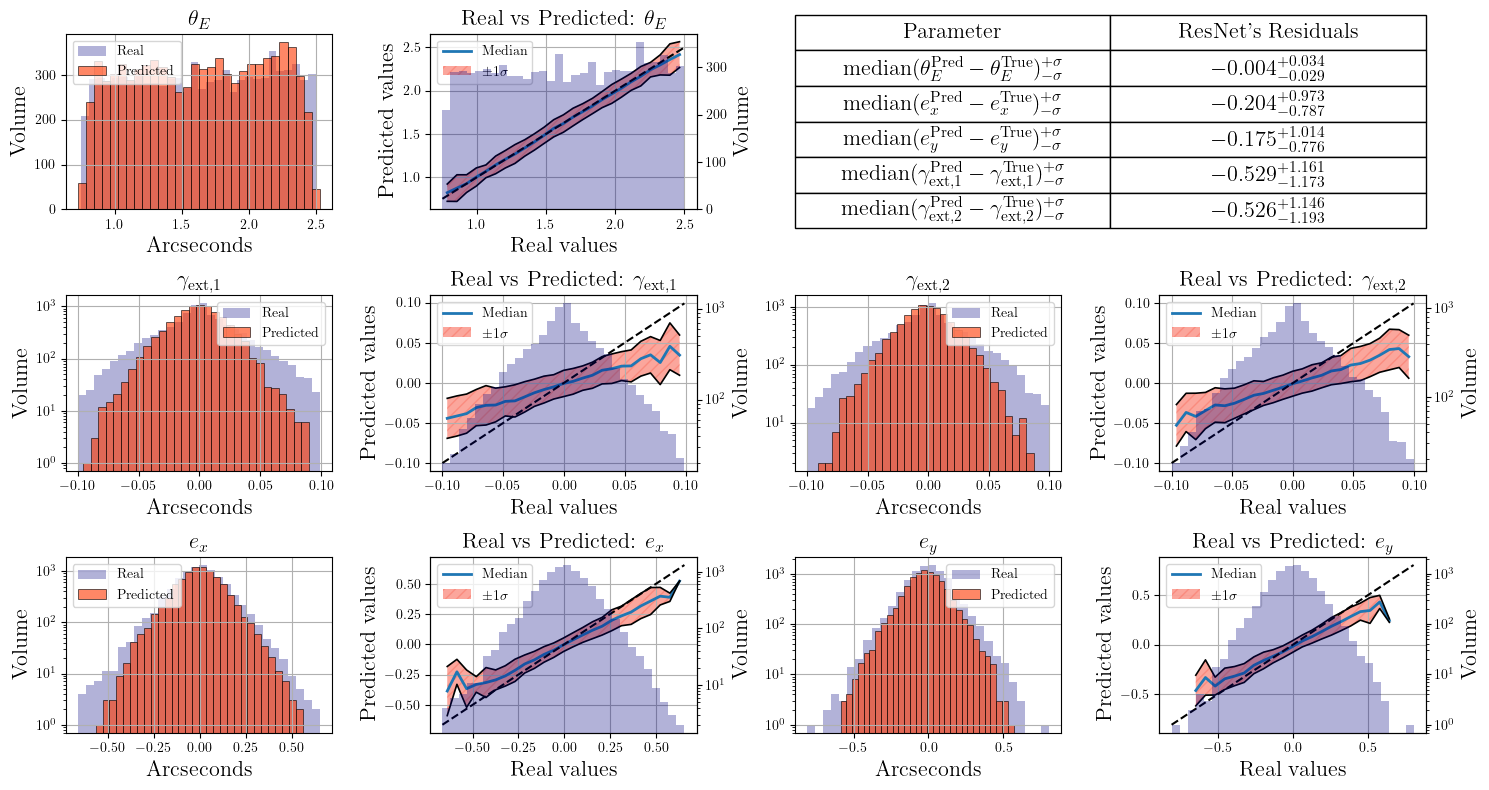

In [46]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

# Min/max used for normalization
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# # # Convert to numpy
# y_true = df_uncertainties[["r_Einstein_t_true",	"gamma1_true",	"gamma2_true",	"ex_true",	"ey_true"]].values
# y_pred = df_uncertainties[["r_Einstein_t_pred",	"gamma1_pred",	"gamma2_pred",	"ex_pred",	"ey_pred"]].values

y_true = targets 
y_pred = preds_mu 

# --- DENORMALIZATION ---
y_true_denorm = y_true * (df_max - df_min) + df_min
y_pred_denorm = y_pred * (df_max - df_min) + df_min

error_denorm = (y_pred_denorm - y_true_denorm)/y_true_denorm

MMedians = np.median(error_denorm, axis=0)
p16 = np.percentile(error_denorm, 16, axis=0)
p84 = np.percentile(error_denorm, 84, axis=0)

sigma_minus = MMedians - p16
sigma_plus  = p84 - MMedians

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]
param_names = [r"$\theta_E$", r"$\gamma_{\mathrm{ext,1}}$", r"$\gamma_{\mathrm{ext,2}}$", r"$e_x$", r"$e_y$"]

fig = plt.figure(figsize=(15, 8))
places = [(1,2), (5,6), (7,8), (9,10), (11,12)]

for i in range(5):

    # --- METRICS ---
    ss_res = np.sum((y_true_denorm[:, i] - y_pred_denorm[:, i])**2)
    ss_tot = np.sum((y_true_denorm[:, i] - np.mean(y_true_denorm[:, i]))**2)
    r2 = 1 - ss_res / ss_tot

    # Histogram comparison
    plt.subplot(3, 4, places[i][0])
    if i == 0: 
        plt.hist(y_true_denorm[:, i], bins=30, alpha=0.3, label="Real", color = '#00007F')
        plt.hist(y_pred_denorm[:, i], bins=30, alpha=0.6, label="Predicted", edgecolor='black',linewidth=0.7, color = '#FF3700')
    else : 
        plt.hist(y_true_denorm[:, i], bins=30, alpha=0.3, label="Real", log = True, color = '#00007F')
        plt.hist(y_pred_denorm[:, i], bins=30, alpha=0.6, label="Predicted", edgecolor='black',linewidth=0.7, log = True, color = '#FF3700')
    plt.title(f"{param_names[i]}", fontsize = 16)
    plt.xlabel('Arcseconds', fontsize = 16)
    plt.legend()
    plt.grid(True)

    # Scatter plot real vs predicted
#     plt.subplot(5, 2, 2*i + 2)

    # Extract the variables
    x = y_true_denorm[:, i]
    y = y_pred_denorm[:, i]
    
    # Define number of bins
    nbins = 25

    # Compute bins
    bins = np.linspace(x.min(), x.max(), nbins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    medians = []
    sigmas = []

    for j in range(nbins):
        mask = (x >= bins[j]) & (x < bins[j+1])
        y_bin = y[mask]

        if len(y_bin) > 0:
            medians.append(np.median(y_bin))
            sigmas.append(np.std(y_bin))
        else:
            medians.append(np.nan)
            sigmas.append(np.nan)

    medians = np.array(medians)
    sigmas = np.array(sigmas)
    
    ax1 = plt.subplot(3, 4,  places[i][1])
    ax2 = ax1.twinx()

    # Plot median curve
    ax1.plot(bin_centers, medians, color="C0", lw=2, label="Median")
    ax1.set_ylabel("Predicted values", fontsize = 16)
    ax1.grid(True)

    # Plot ±1σ band
    ax1.fill_between(
        bin_centers,
        medians - sigmas,
        medians + sigmas,
        color="salmon",
        alpha=0.7,
        hatch="///",          # crosshatch style
        linewidth=0.0,        # avoid thick borders around the whole patch
        label="$\pm 1 \sigma$"
    )
    
    ax1.plot(bin_centers, medians - sigmas, color="black", linewidth=1.2)
    ax1.plot(bin_centers, medians + sigmas, color="black", linewidth=1.2)
    
    # 1:1 line
    # min_val = min(x.min(), y.min())
    # max_val = max(x.max(), y.max())
    x_diag = np.linspace(x.min(), x.max(), 100)
    ax1.plot(x_diag, x_diag, "k--", lw=1.5)
    if i == 0 :
        ax2.hist(y_true_denorm[:, i], bins=30, alpha=0.3, color = '#00007F')
    else :
        ax2.hist(y_true_denorm[:, i], bins=30, alpha=0.3, log = True, color = '#00007F')
    ax2.set_ylabel("Volume", fontsize = 16)
    
    ax1.set_xlabel("Real values", fontsize = 16)
    ax1.legend()
    plt.title(f"Real vs Predicted: {param_names[i]}", fontsize = 16)
#     plt.grid(True)
#     plt.legend()


PPP = [(1,2), (5,6), (9,10)]
for jj in PPP:
    ax1 = plt.subplot(3, 4,  jj[0])
    ax1.set_ylabel('Volume', fontsize = 16)

    # --- Add text box with denormalised stats ---
# ax = plt.subplot(3, 4, 3)
# ax.axis("off")
data = [
    [r"median$(\theta_E^{\mathrm{Pred}}- \theta_E^{\mathrm{True}})^{+ \sigma}_{- \sigma}$", fr"${MMedians[0]:.3f}_{{-{sigma_minus[0]:.3f}}}^{{+{sigma_plus[0]:.3f}}}$"],
    [r"median$(e_x^{\mathrm{Pred}} - e_x^{\mathrm{True}})^{+\sigma}_{-\sigma}$", fr"${MMedians[3]:.3f}_{{-{sigma_minus[3]:.3f}}}^{{+{sigma_plus[3]:.3f}}}$"],
    [r"median$(e_y^{\mathrm{Pred}} - e_y^{\mathrm{True}})^{+\sigma}_{-\sigma}$", fr"${MMedians[4]:.3f}_{{-{sigma_minus[4]:.3f}}}^{{+{sigma_plus[4]:.3f}}}$"],
    ["median$(\gamma_{\mathrm{ext, 1}}^{\mathrm{Pred}} - \gamma_{\mathrm{ext,1}}^{\mathrm{True}})^{+\sigma}_{-\sigma}$", fr"${MMedians[1]:.3f}_{{-{sigma_minus[1]:.3f}}}^{{+{sigma_plus[1]:.3f}}}$"],
    ["median$(\gamma_{\mathrm{ext,2}}^{\mathrm{Pred}} - \gamma_{\mathrm{ext, 2}}^{\mathrm{True}})^{+\sigma}_{-\sigma}$", fr"${MMedians[2]:.3f}_{{-{sigma_minus[2]:.3f}}}^{{+{sigma_plus[2]:.3f}}}$"],
]

gs = fig.add_gridspec(3, 4)
ax_table = fig.add_subplot(gs[0, 2:4])  
ax_table.axis("off")

table = ax_table.table(
    cellText=data,
    colLabels=["Parameter", "ResNet's Residuals"],
    loc="center",
    cellLoc="center",   # <-- centers text in ALL cells
    colLoc="center"     # <-- centers column labels
)

# Style cells
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        
table.auto_set_font_size(False)
table.set_fontsize(16)
table.scale(1, 2.2)
plt.tight_layout()
plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/bayes_results.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

# Min/max used for normalization
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# # # Convert to numpy
# y_true = df_uncertainties[["r_Einstein_t_true",	"gamma1_true",	"gamma2_true",	"ex_true",	"ey_true"]].values
# y_pred = df_uncertainties[["r_Einstein_t_pred",	"gamma1_pred",	"gamma2_pred",	"ex_pred",	"ey_pred"]].values

y_true = targets 
y_pred = preds_mu 

# --- DENORMALIZATION ---
y_true = y_true * (df_max - df_min) + df_min
y_pred = y_pred * (df_max - df_min) + df_min

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]
param_names = [r"$\Delta \ \theta_E$", r"$\Delta \ \gamma_1$", r"$\Delta \ \gamma_2$", r"$\Delta \ e_x$", r"$\Delta \ e_y$"]

y_true = np.array(y_true)
y_pred = np.array(y_pred)

residuals = y_pred - y_true   # shape: (N, 5)
n_params = residuals.shape[1]

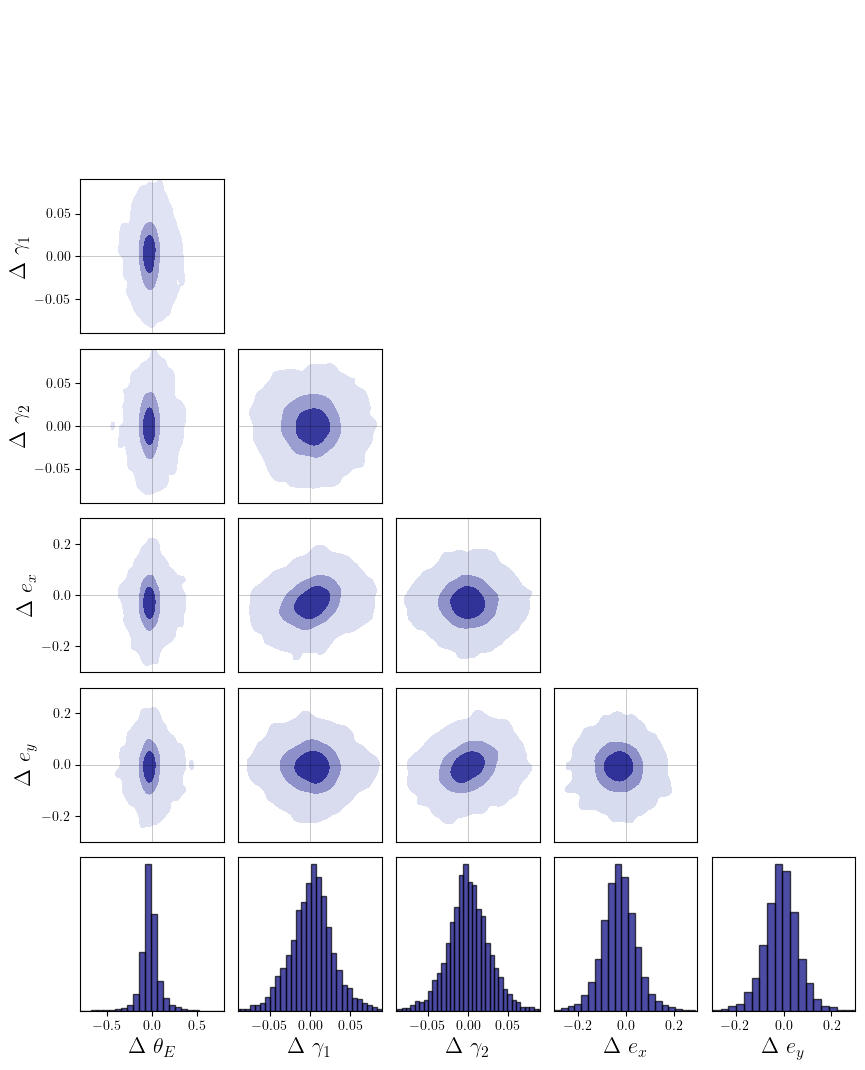

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

from matplotlib.colors import LinearSegmentedColormap

custom_blues = LinearSegmentedColormap.from_list(
    "custom_blues",
    ["#f7fbff", "#00007F"]  # light → your exact dark blue
)

fig, axes = plt.subplots(n_params + 1, n_params, figsize=(10, 13))
plt.subplots_adjust(wspace=0.1, hspace=0.1)

for i in range(n_params):
    for j in range(n_params):

        ax = axes[i, j]

        if i > j:
            # KDE contours
            sns.kdeplot(
                x=residuals[:, j],
                y=residuals[:, i],
                levels=4,
                linewidths=1.2,
                color = 'black',
                cmap=custom_blues, # cmap="Blues", #Blues #00007F
                fill=True,
                alpha=1,
                ax=ax
            )

            # zero reference lines (VERY useful visually)
            ax.axhline(0, color="black", lw=0.5, alpha=0.3)
            ax.axvline(0, color="black", lw=0.5, alpha=0.3)
        else:
            ax.axis("off")
        if i < 3:
            ax.set_ylim([-0.09, 0.09])
        else : 
            ax.set_ylim([-0.3, 0.3])
        if j == 0:
            ax.set_xlim([-0.8, 0.8])
        elif j < 3:
            ax.set_xlim([-0.09, 0.09])
        else:
            ax.set_xlim([-0.3, 0.3])

        # axis labels (FIXED CONDITION)
        if i == n_params :
            ax.set_xlabel(param_names[j], fontsize = 20)
        else:
            ax.set_xticks([])

        if j == 0 and i != j:
            ax.set_ylabel(param_names[i], fontsize = 16)
        else:
            ax.set_yticks([])
            

# bottom row histograms
for k in range(n_params):
    ax = axes[-1, k]
    ax.hist(residuals[:, k], bins=40, edgecolor="black", color = '#00007F', alpha = 0.7)
    ax.set_xlabel(param_names[k], fontsize = 16)
    ax.set_yticks([])
    if k == 0:
        ax.set_xlim([-0.8, 0.8])
    elif k < 3:
        ax.set_xlim([-0.09, 0.09])
    else:
        ax.set_xlim([-0.3, 0.3])
plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/degenerency.png", dpi=300, bbox_inches="tight")
plt.show()

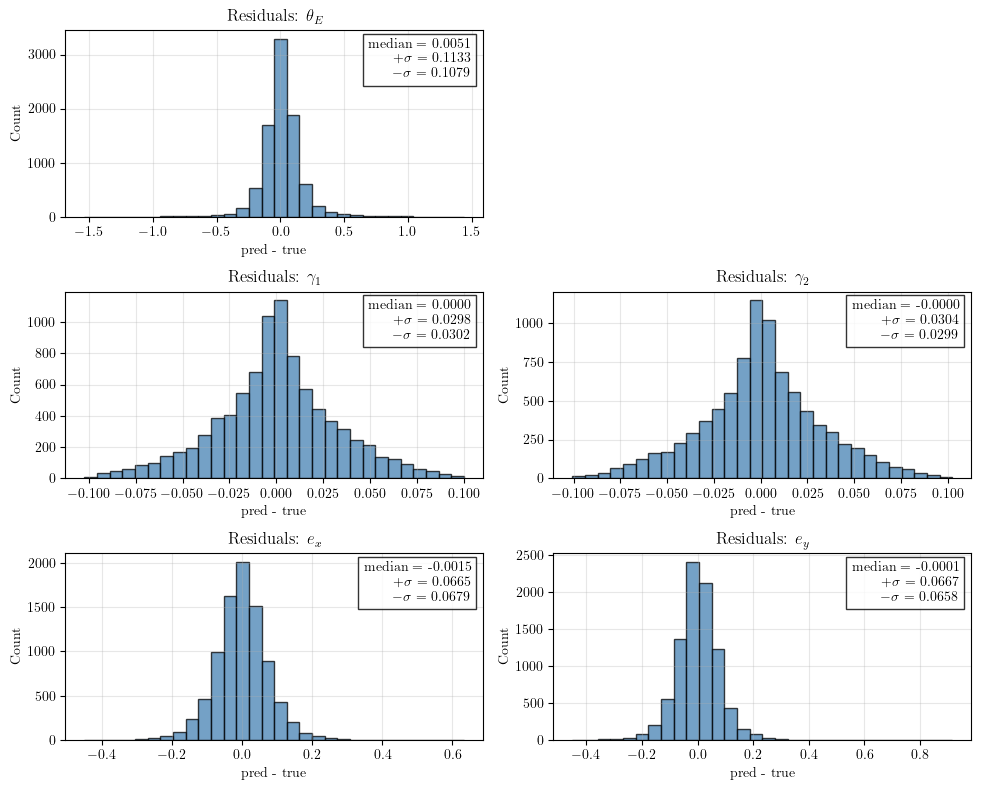

In [33]:
import torch
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

# Min/max used for normalization
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# # Convert to numpy
y_true = df_uncertainties[["r_Einstein_t_true",	"gamma1_true",	"gamma2_true",	"ex_true",	"ey_true"]].values
y_pred = df_uncertainties[["r_Einstein_t_pred",	"gamma1_pred",	"gamma2_pred",	"ex_pred",	"ey_pred"]].values


# y_true = targets 
# y_pred = preds_mu 

# --- DENORMALIZATION ---
y_true_denorm = y_true * (df_max - df_min) + df_min
y_pred_denorm = y_pred * (df_max - df_min) + df_min

# --- Compute denormalised errors ---
error_denorm = y_pred_denorm - y_true_denorm

# --- Asymmetric statistics ---
medians = np.median(error_denorm, axis=0)
p16 = np.percentile(error_denorm, 16, axis=0)
p84 = np.percentile(error_denorm, 84, axis=0)

sigma_minus = medians - p16
sigma_plus  = p84 - medians

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]
param_names = [r"$\theta_E$", r"$\gamma_1$", r"$\gamma_2$", r"$e_x$", r"$e_y$"]

# --- Plot ---
fig, axes = plt.subplots(3, 2, figsize=(10, 8))
axes = axes.flatten()  
poss = [1,3,4,5,6]

for i in range(error_denorm.shape[1]):
    plt.subplot(3, 2, poss[i])
    plt.hist(error_denorm[:, i], bins=30, alpha=0.75,
             color="steelblue", edgecolor="black")
    plt.title(f"Residuals: {param_names[i]}")
    plt.xlabel("pred - true")
    plt.ylabel("Count")
    plt.grid(alpha=0.3)

    # --- Add text box with denormalised stats ---
    text = (
        f"median = {medians[i]:.4f}\n"
        f"$+ \sigma$ = {sigma_plus[i]:.4f}\n"
        f"$- \sigma$ = {sigma_minus[i]:.4f}"
    )

    plt.text(
        0.97, 0.95, text,
        transform=plt.gca().transAxes,
        fontsize=10,
        ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
    )

plt.tight_layout()
axes[1].axis("off")
plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/resnet_hist_residus.png", dpi=300, bbox_inches="tight")
plt.show()

In [32]:
SS = [0.6486486486486487,
 0.8848848848848849,
 0.8968968968968969,
 0.7447447447447447,
 0.6766766766766766]

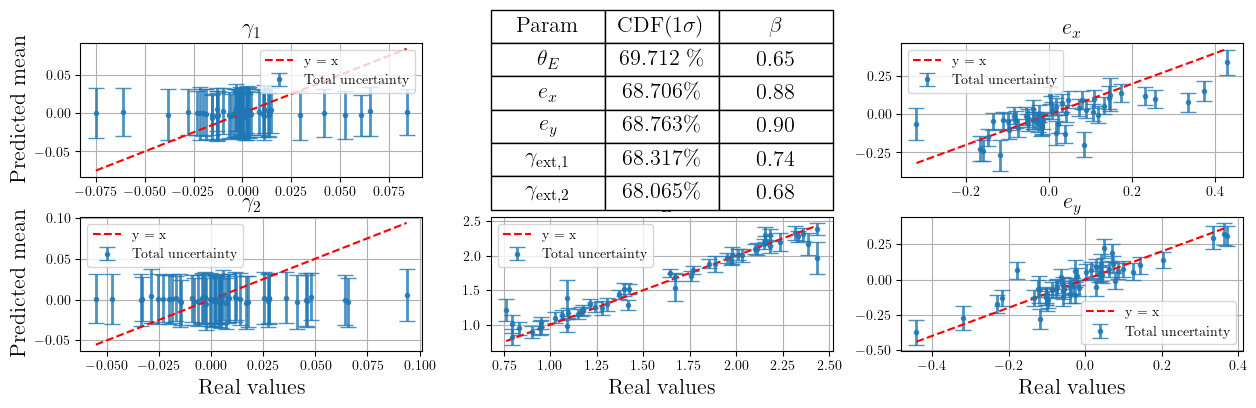

In [33]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

y_true = df_uncertainties[["r_Einstein_t_true",	"gamma1_true",	"gamma2_true",	"ex_true",	"ey_true"]].values
y_pred = df_uncertainties[["r_Einstein_t_pred",	"gamma1_pred",	"gamma2_pred",	"ex_pred",	"ey_pred"]].values

# --- DENORMALIZATION ---
y_true_denorm = y_true * (df_max - df_min) + df_min
y_pred_denorm = y_pred * (df_max - df_min) + df_min

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]
param_names = [r"$\theta_E$", r"$\gamma_1$", r"$\gamma_2$", r"$e_x$", r"$e_y$"]
V = 50

plt.figure(figsize=(15, 4))
places = [1,3,4,5,6]
places = [5,1,4,3,6]

all_aleatoric = df_uncertainties[['r_Einstein_t_aleatoric', 'gamma1_aleatoric', 'gamma2_aleatoric',
       'ex_aleatoric', 'ey_aleatoric']].values
all_epistemic = df_uncertainties[['r_Einstein_t_epistemic',
       'gamma1_epistemic', 'gamma2_epistemic', 'ex_epistemic', 'ey_epistemic']].values

all_aleatoric = np.sqrt(np.exp(all_aleatoric))
all_epistemic = all_epistemic

unc_tot = np.sqrt(all_aleatoric**2 + all_epistemic**2) * SS * (df_max - df_min)
coverage  = []
for i in range(5):
    
    true_values = y_true_denorm[:V,i]
    pred_mean = y_pred_denorm[:V,i]
    pred_epis = all_epistemic[:V,i]
    pred_alea = all_aleatoric[:V,i]
    unc_tot_i = unc_tot[:V,i]

    inside = np.abs(y_true_denorm[:,i] - y_pred_denorm[:,i]) <=  unc_tot[:,i]
    coverage.append(inside.mean() * 100)

    plt.subplot(2, 3, places[i])
    plt.subplots_adjust(wspace=0.2, hspace=0.3)

    plt.errorbar(true_values, pred_mean, 
                 yerr=unc_tot_i, 
                 fmt='o', 
                 markersize=3,
                 alpha=0.8, 
                 capsize=6,
                label = 'Total uncertainty', linewidth = 2)
    min_val = min(true_values.min(), pred_mean.min())
    max_val = max(true_values.max(), pred_mean.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')
    if places[i] ==1 or places[i] == 4:
        plt.ylabel("Predicted mean", fontsize = 16)
    if places[i]>= 4:
        plt.xlabel("Real values", fontsize = 16)
    plt.title(f"{param_names[i]}", fontsize = 16)
    plt.legend()
    # plt.xticks(fontsize = 16)
    # plt.yticks(fontsize = 16)
    plt.grid(True)

data = [
    [r"$\theta_E$", fr"${coverage[0]:.3f}$ \%", "0.65"],
    [r"$e_x$", fr"${coverage[3]:.3f}$\%", "0.88"],
    [r"$e_y$", fr"${coverage[4]:.3f}$\%", "0.90"],
    ["$\gamma_{\mathrm{ext, 1}}$", fr"${coverage[1]:.3f}$\%", "0.74"],
    ["$\gamma_{\mathrm{ext,2}}$", fr"${coverage[2]:.3f}$\%", "0.68"],
]

ax_table = plt.subplot(2, 3, 2)
ax_table.axis("off")

table = ax_table.table(
    cellText=data,
    colLabels=["Param", "CDF(1$\sigma$)", r"$\beta$"],
    loc="center",
    cellLoc="center",   # <-- centers text in ALL cells
    colLoc="center"     # <-- centers column labels
)

# Style cells
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
table.auto_set_font_size(False)
table.set_fontsize(16)
table.scale(1, 2)
# plt.tight_layout()
plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/uncertainty_para.png", dpi=300, bbox_inches="tight")
plt.show()


In [53]:
pwd

'/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing'

In [55]:
df_uncertainties

,r_Einstein_t_true,gamma1_true,gamma2_true,ex_true,ey_true,r_Einstein_t_pred,gamma1_pred,gamma2_pred,ex_pred,ey_pred,...,gamma1_aleatoric,gamma2_aleatoric,ex_aleatoric,ey_aleatoric,r_Einstein_t_epistemic,gamma1_epistemic,gamma2_epistemic,ex_epistemic,ey_epistemic,Paths
0,0.895991,0.421908,0.407725,0.384821,0.506791,0.899592,0.470452,0.504913,0.331544,0.538324,...,-3.578040,-3.587664,-5.891966,-5.966834,0.053710,0.009875,0.007886,0.032641,0.015612,NaN
1,0.006785,0.498224,0.496970,0.466943,0.435864,0.266441,0.497370,0.500765,0.466898,0.430797,...,-3.319193,-3.419791,-5.995601,-6.000000,0.048465,0.002908,0.005559,0.013145,0.012409,NaN
2,0.177612,0.512140,0.639151,0.612127,0.514790,0.222553,0.524211,0.504193,0.590613,0.549167,...,-3.541464,-3.526169,-5.972385,-5.992722,0.039164,0.006553,0.007194,0.020971,0.017881,NaN
3,0.085871,0.543400,0.480554,0.505455,0.499035,0.079589,0.508878,0.504265,0.527478,0.529873,...,-3.520636,-3.525352,-5.999567,-6.000000,0.048041,0.004004,0.008365,0.013435,0.013712,NaN
4,0.779045,0.920428,0.639357,0.721708,0.539079,0.768818,0.509320,0.510194,0.546783,0.611760,...,-3.533502,-3.555429,-5.886550,-5.993771,0.035517,0.006515,0.009806,0.019793,0.025568,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8741,0.925814,0.278565,0.337357,0.511276,0.456869,0.891863,0.496396,0.501263,0.481737,0.424365,...,-3.521178,-3.553129,-5.994533,-6.000000,0.047531,0.004350,0.007320,0.013673,0.018975,NaN
8742,0.703916,0.515615,0.821545,0.302522,0.345264,0.512243,0.474287,0.491710,0.296489,0.403590,...,-3.439332,-3.490301,-5.150413,-5.412495,0.047374,0.008934,0.008301,0.032476,0.025780,NaN
8743,0.533192,0.989708,0.569939,0.578675,0.403395,0.572176,0.517540,0.482601,0.581387,0.429953,...,-3.532497,-3.552601,-5.996883,-6.000000,0.024018,0.006362,0.006618,0.017916,0.014990,NaN
8744,0.483549,0.671676,0.701700,0.495656,0.502268,0.512973,0.500254,0.518965,0.498757,0.554123,...,-3.531118,-3.572946,-6.000000,-6.000000,0.015998,0.004506,0.004615,0.010537,0.013086,NaN


[5611 7581 6949 2433 5311 5051 6420 1184]


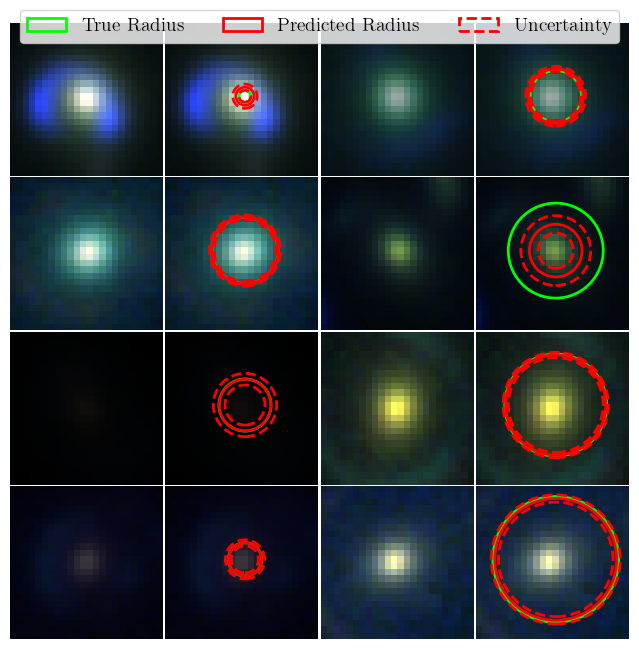

In [35]:
indexx = np.random.randint(0,8000,8)
print(indexx)
fig, axis = plt.subplots(4,4, figsize = (8,8))
fig.subplots_adjust(wspace=0.01, hspace=0.01)
axis = axis.flatten()

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

d = 0
for k in range(len(indexx)):
    index = indexx[k]
    folder = "/home/rcanameras/data/mock_lenses_hsc"
    file = os.path.join(folder, df_uncertainties.Paths[index])
    # print("Opening:", file)
    
    true_value = df_uncertainties.r_Einstein_t_true[index]* 1.75
    pred_value = df_uncertainties.r_Einstein_t_pred[index] * 1.75
    std_alea = np.sqrt(np.exp(df_uncertainties.r_Einstein_t_aleatoric[index])) * 1.75
    sigma = np.sqrt(std_alea**2 + (df_uncertainties.r_Einstein_t_epistemic[index] * 1.75)**2) * SS[0]
    # sigma = np.sqrt(df_uncertainties.r_Einstein_t_aleatoric[index]**2)  * s_opt * 1.75
    
    with fits.open(file) as hdul:
        images = [hdul[i].data for i in range(1, len(hdul))]
    images = images[::2]
    # fig, axes = plt.subplots(1, 4, figsize=(15, 10))
    bandes = ['g', 'r', 'i', 'z']
    
    w1, w2 = 108, 60 # image will be of dimension w2-w1 x w2-w1
    
    with fits.open(file) as hdul:
        g = hdul[1].data
        r = hdul[3].data
        i = hdul[5].data
        z = hdul[7].data
        
    R, G, B = i, r, g
    
    def norm(x):
        x = x - np.nanmin(x)
        x = x / np.nanmax(x)
        return x
    
    Rn, Gn, Bn = norm(R)[w1:-w1,w1:-w1], norm(G)[w1:-w1,w1:-w1], norm(B)[w1:-w1,w1:-w1]
    
    rgb = np.dstack([Rn, Gn, Bn])
    
    axis[d].imshow(rgb, origin='lower')
    # axis[d].set_title("Lensing image")
    axis[d].axis('off')
    
    # Right image
    axis[d +1].imshow(rgb, origin='lower')
    # axis[d +1].set_title("Radius Comparison")
    axis[d +1].axis('off')
    
    H, W = rgb.shape[:2]
    cx, cy = W/2, H/2
    
    # True Einstein radius (green)
    circle_true = plt.Circle(
        (cx, cy),
        true_value/ 0.168,
        color='lime',
        fill=False,
        linewidth=2,
        label='True Radius'
    )
    axis[d+1].add_patch(circle_true)
    
    # Predicted Einstein radius (red)
    circle_pred = plt.Circle(
        (cx, cy),
        pred_value/ 0.168,
        color='red',
        fill=False,
        linewidth=2,
        label='Predicted Radius'
    )
    axis[d +1].add_patch(circle_pred)
    
    # Predicted Einstein radius (red)
    circle_pred_sig_p = plt.Circle((cx, cy), pred_value/0.168 + sigma/0.168,
                             color='red', fill=False, linewidth=2, linestyle = '--')
    axis[d +1].add_patch(circle_pred_sig_p)
    
    # Predicted Einstein radius (red)
    circle_pred_m = plt.Circle((cx, cy), pred_value/0.168 - sigma/0.168,
                             color='red', fill=False, linewidth=2, linestyle = '--', label='Uncertainty')
    axis[d +1].add_patch(circle_pred_m)
    
    # # Add legend
    # axis[d +1].legend(loc='upper right', fontsize=12)
    d += 2
# plt.tight_layout()
axis[3].legend(
    loc='upper right',
    bbox_to_anchor=(1, 1.15),
    ncol=3,
    fontsize=14
)
plt.savefig("predspreds.png")
plt.show()

In [ ]:
sigma

Opening: /home/rcanameras/data/mock_lenses_hsc/final_hscsearch_2e3_17/lens_32956_source_2377_r_0.fits


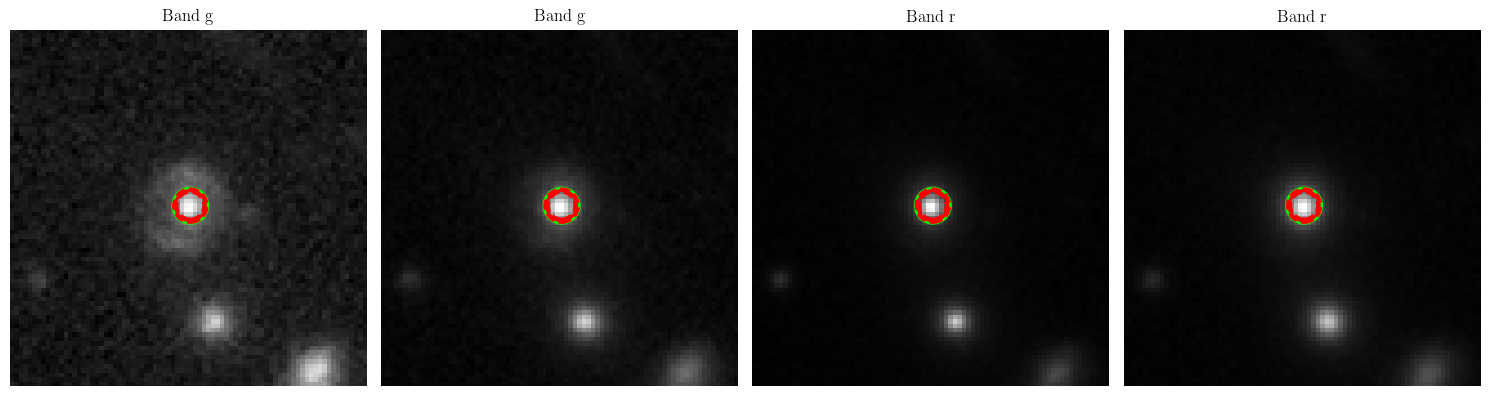

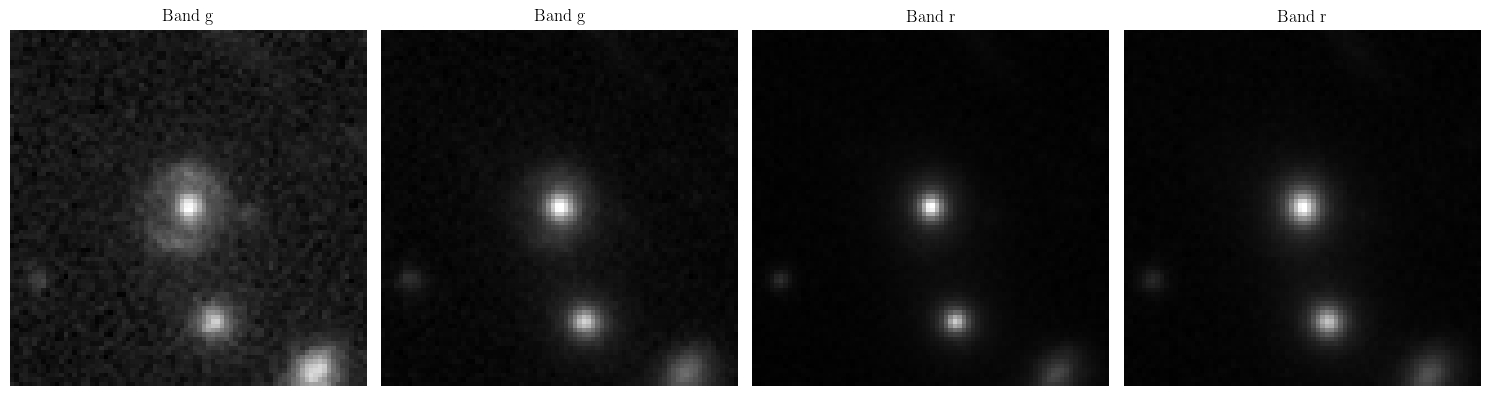

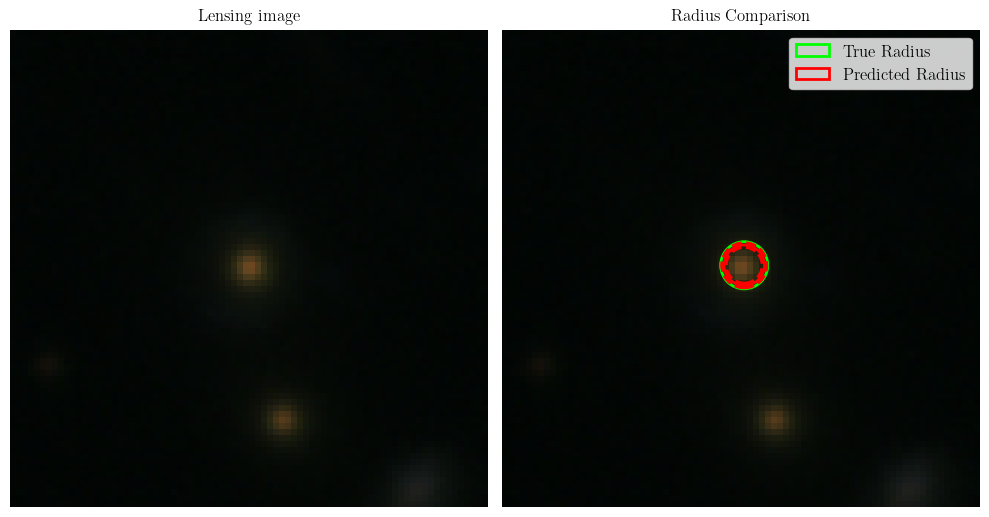

In [93]:
index = 8

folder = "/home/rcanameras/data/mock_lenses_hsc"
file = os.path.join(folder, df_uncertainties.Paths[index])
print("Opening:", file)


true_value = df_uncertainties.r_Einstein_t_true[index]* 1.75
pred_value = df_uncertainties.r_Einstein_t_pred[index] * 1.75
std_alea = np.sqrt(np.exp(df_uncertainties.r_Einstein_t_aleatoric[index])) * 1.75 * s_opt
sigma = np.sqrt(std_alea**2 + df_uncertainties.r_Einstein_t_epistemic[index]**2)
# sigma = np.sqrt(df_uncertainties.r_Einstein_t_aleatoric[index]**2)  * s_opt * 1.75

with fits.open(file) as hdul:
    images = [hdul[i].data for i in range(1, len(hdul))]
images = images[::2]
fig, axes = plt.subplots(1, 4, figsize=(15, 10))
bandes = ['g', 'r', 'i', 'z']

w1, w2 = 80, 60 # image will be of dimension w2-w1 x w2-w1

for ax, img, idx in zip(axes.ravel(), images, range(0, len(images))):
    img = img[w1:-w1,w1:-w1]
    im = ax.imshow(img, origin='lower', cmap='gray')
#     fig.colorbar(im, ax=ax)
    ax.set_title(f"Band  {bandes[idx//2]}")
    ax.axis('off')
    H, W = img.shape
    cx, cy = W/2, H/2

    # True Einstein radius (green)
    circle_true = plt.Circle((cx, cy), true_value/0.168,
                             color='lime', fill=False, linewidth=2)
    ax.add_patch(circle_true)

    # Predicted Einstein radius (red)
    circle_pred = plt.Circle((cx, cy), pred_value/0.168,
                             color='red', fill=False, linewidth=2)
    ax.add_patch(circle_pred)

    # Predicted Einstein radius (red)
    circle_pred_sig_p = plt.Circle((cx, cy), pred_value/0.168 + sigma/0.168,
                             color='red', fill=False, linewidth=2, linestyle = '--')
    ax.add_patch(circle_pred_sig_p)

    # Predicted Einstein radius (red)
    circle_pred_m = plt.Circle((cx, cy), pred_value/0.168 - sigma/0.168,
                             color='red', fill=False, linewidth=2, linestyle = '--')
    ax.add_patch(circle_pred_m)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(15, 10))
bandes = ['g', 'r', 'i', 'z']
for ax, img, idx in zip(axes.ravel(), images, range(0, len(images))):
    img = img[w1:-w1,w1:-w1]
    im = ax.imshow(img, origin='lower', cmap='gray')
#     fig.colorbar(im, ax=ax)
    ax.set_title(f"Band  {bandes[idx//2]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

with fits.open(file) as hdul:
    g = hdul[1].data
    r = hdul[3].data
    i = hdul[5].data
    z = hdul[7].data
    
R, G, B = i, r, g

def norm(x):
    x = x - np.nanmin(x)
    x = x / np.nanmax(x)
    return x

Rn, Gn, Bn = norm(R)[w1:-w1,w1:-w1], norm(G)[w1:-w1,w1:-w1], norm(B)[w1:-w1,w1:-w1]

rgb = np.dstack([Rn, Gn, Bn])

fig, axis = plt.subplots(1,2, figsize=(10,10))
axis[0].imshow(rgb, origin='lower')
axis[0].set_title("Lensing image")
axis[0].axis('off')

# Right image
axis[1].imshow(rgb, origin='lower')
axis[1].set_title("Radius Comparison")
axis[1].axis('off')

H, W = img.shape
cx, cy = W/2, H/2

# True Einstein radius (green)
circle_true = plt.Circle(
    (cx, cy),
    true_value/ 0.168,
    color='lime',
    fill=False,
    linewidth=2,
    label='True Radius'
)
axis[1].add_patch(circle_true)

# Predicted Einstein radius (red)
circle_pred = plt.Circle(
    (cx, cy),
    pred_value/ 0.168,
    color='red',
    fill=False,
    linewidth=2,
    label='Predicted Radius'
)
axis[1].add_patch(circle_pred)

# Predicted Einstein radius (red)
circle_pred_sig_p = plt.Circle((cx, cy), pred_value/0.168 + sigma/0.168,
                         color='red', fill=False, linewidth=2, linestyle = '--')
axis[1].add_patch(circle_pred_sig_p)

# Predicted Einstein radius (red)
circle_pred_m = plt.Circle((cx, cy), pred_value/0.168 - sigma/0.168,
                         color='red', fill=False, linewidth=2, linestyle = '--')
axis[1].add_patch(circle_pred_m)


# Add legend
axis[1].legend(loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

In [56]:
sigma

5.626371143510226

In [54]:
import numpy as np

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

scale = (df_max - df_min)

# --- denormalize uncertainties ---
aleatoric_denorm = np.sqrt(np.exp(df_uncertainties.r_Einstein_t_aleatoric.values)) * 1.75 * s_opt
epistemic_denorm = df_uncertainties.r_Einstein_t_epistemic.values
# epistemic_denorm = 0
sigma_total = np.sqrt(aleatoric_denorm**2 + epistemic_denorm**2)

# --- coverage results -
name = "r_Einstein"
true_value = df_uncertainties.r_Einstein_t_true.values * 1.75
pred_value = df_uncertainties.r_Einstein_t_pred.values * 1.75

true = true_value
pred = pred_value
sigma = sigma_total

inside = np.abs(pred - true) <=  sigma
coverage = inside.mean()

# coverage_results[name] = coverage

print(f"{name}:")
print(f"  coverage (±1σ): {coverage:.3f}")
print(f"  expected ~0.683 for Gaussian\n")

r_Einstein:
  coverage (±1σ): 0.547
  expected ~0.683 for Gaussian



In [53]:
import numpy as np

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

scale = (df_max - df_min)

    std_alea = np.sqrt(np.exp(df_uncertainties.r_Einstein_t_aleatoric[index])) * 1.75 * s_opt
    sigma = np.sqrt(std_alea**2 + (df_uncertainties.r_Einstein_t_epistemic[index] * 1.75)**2) 

# --- denormalize uncertainties ---
aleatoric_denorm = np.sqrt(np.exp(df_uncertainties.r_Einstein_t_aleatoric.values)) * 1.75 * s_opt
epistemic_denorm = df_uncertainties.r_Einstein_t_epistemic.values

sigma_total = np.sqrt(aleatoric_denorm**2 + epistemic_denorm**2)

# --- coverage results ---
coverage_results = {}

for i, name in enumerate(param_names):

    true = y_true_denorm[:, i]
    pred = y_pred_denorm[:, i]
    sigma = sigma_total[:, i]

    inside = np.abs(pred - true) <=  sigma
    coverage = inside.mean()

    coverage_results[name] = coverage

    print(f"{name}:")
    print(f"  coverage (±1σ): {coverage:.3f}")
    print(f"  expected ~0.683 for Gaussian\n")

IndentationError: unexpected indent (3298427763.py, line 7)

In [30]:
y_true_denorm[:, 0]

array([2.31794933, 0.76188982, 1.06082727, ..., 1.68307172, 1.59619844,
       0.87204213])

In [31]:
y_pred_denorm[:, 0]

array([2.36333447, 0.87043438, 1.17867963, ..., 1.48336583, 1.63909813,
       0.9491136 ])

In [32]:
sigma_total[:, 0]

array([0.03439901, 0.01968476, 0.02065361, ..., 0.02372728, 0.03476265,
       0.02199985])

In [34]:
aleatoric_denorm[:,0]

array([0.01179102, 0.01179102, 0.01179102, ..., 0.01179102, 0.01179102,
       0.01179102])

In [35]:
epistemic_denorm[:,0]

array([0.03231507, 0.01576267, 0.0169571 , ..., 0.02059019, 0.03270189,
       0.01857324])

In [33]:
df_max - df_min

array([1.74994198, 0.19998031, 0.19982033, 1.46756378, 1.66341667])

In [ ]:
plt.hist(epistemic_denorm[:, 0], log = True, bins = 50, alpha = 0.6, edgecolor = 'black')
plt.title('Total uncertainty histogram on the Einstein Radius', fontsize = 18)
plt.xlabel('$\sigma$ Total', fontsize = 16)
plt.ylabel('Volume', fontsize = 16)
plt.grid(True)
plt.show()

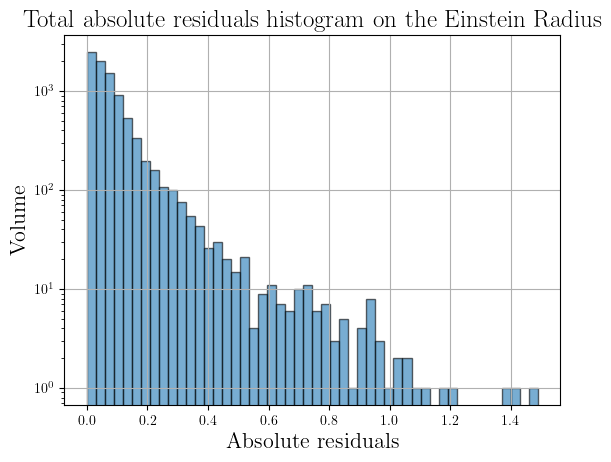

In [46]:
plt.hist(abs(y_true_denorm[:, 0] - y_pred_denorm[:, 0]), log = True, bins = 50, alpha = 0.6, edgecolor = 'black')
plt.title('Total absolute residuals histogram on the Einstein Radius', fontsize = 18)
plt.xlabel('Absolute residuals', fontsize = 16)
plt.ylabel('Volume', fontsize = 16)
plt.grid(True)
plt.show()